In [1]:
# baseline.ipynb
# Integrated Baseline: Socioeconomic Indicators for Train Delay Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, balanced_accuracy_score, roc_auc_score, f1_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [2]:
# 1. DATA LOADING & CONTEXTUALIZATION
# Based on your EDA, we load the merged dataset containing Operational, KNMI, and CBS data.
def load_and_preprocess(file_path='C:/Users/EduardCP/Documents/GitHub/MasterThesis/data/processed/final_dataset.parquet'):
    df = pd.read_parquet(file_path)
    
    # Create the 'Remoteness' proxy identified in your EDA
    if 'source_Dist_Highway_Entrance' in df.columns:
        df['source_Remoteness_Index'] = (df['source_Dist_Highway_Entrance'] + 
                                  df['source_Dist_Major_Transfer_Station']) / 2
        df['target_Remoteness_Index'] = (df['target_Dist_Highway_Entrance'] + 
                                  df['target_Dist_Major_Transfer_Station']) / 2
    
    # Define Target
    target = 'Disrupted'
    
    return df, target

In [3]:
df, target = load_and_preprocess()

In [4]:
# 2. FEATURE SELECTION STRATEGY
def get_feature_groups():
    # Grouping features to allow for "A/B" baseline testing
    operational_features = ['rides_planned', 'disruption_count', 'stop_count']
    weather_features = ['DR', 'RH', 'SQ', 'TG', 'TN', 'TX', 'RHX'] # KNMI features

    # Your core research contribution: Socioeconomic Indicators
    socioeconomic_features = [
        'target_SES_Score_Wealth_Avg', 'target_SES_Score_Education_Avg', 'target_TotalVandalism', 'target_Remoteness_Index',
                'source_SES_Score_Wealth_Avg', 'source_SES_Score_Education_Avg', 'source_TotalVandalism', 'source_Remoteness_Index']
    
    return operational_features + weather_features, socioeconomic_features

In [5]:
# 3. BASELINE MODEL IMPLEMENTATION (Derived from Models.ipynb)
def run_baseline_comparison(df, target):
    base_feats, ses_feats = get_feature_groups()
    
    # Scenario A: Only Operational + Weather
    # Scenario B: Operational + Weather + Socioeconomic
    scenarios = {
        "Standard Baseline": base_feats,
        "Socioeconomic Enhanced": base_feats + ses_feats
    }
    
    results = {}
    
    for name, features in scenarios.items():
        print(f"--- Running Scenario: {name} ---")
        
        # Filter for available columns to prevent crashes
        available_features = [f for f in features if f in df.columns]
        X = df[available_features].fillna(0)
        y = df[target]
        
        # Time-based or Random split (Random used here for baseline simplicity)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
        
        # Handle Imbalance using SMOTE as seen in Tier 1 methodology
        sm = SMOTE(random_state=42)
        X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
        
        # Initialize XGBoost (The high-performance baseline from the paper)
        model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_estimators=100)
        model.fit(X_train_res, y_train_res)
        
        # Evaluation
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]
        
        results[name] = {
            'Balanced Accuracy': balanced_accuracy_score(y_test, preds),
            'F1-Score': f1_score(y_test, preds),
            'AUC': roc_auc_score(y_test, probs)
        }
        
    return results

--- Running Scenario: Standard Baseline ---


c:\Users\EduardCP\Documents\GitHub\MasterThesis\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:10:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Running Scenario: Socioeconomic Enhanced ---


c:\Users\EduardCP\Documents\GitHub\MasterThesis\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:11:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


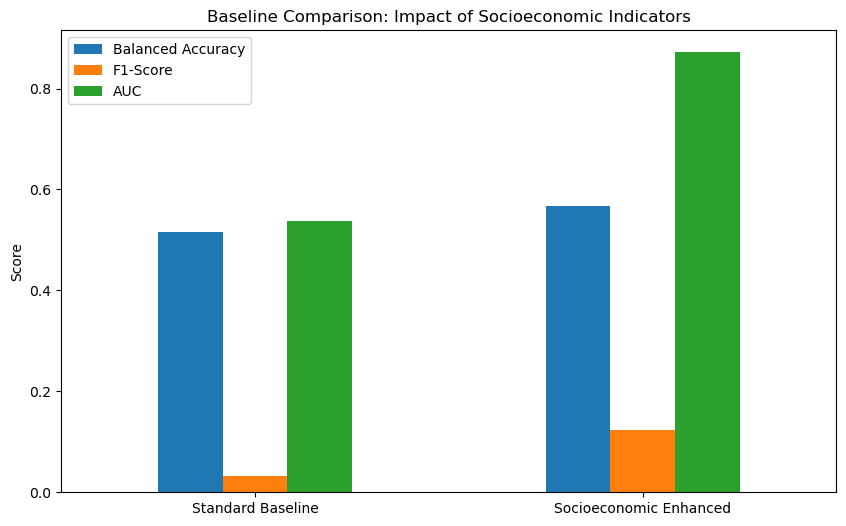


Final Performance Metrics:
                        Balanced Accuracy  F1-Score       AUC
Standard Baseline                0.515344  0.031951  0.537304
Socioeconomic Enhanced           0.567154  0.123523  0.871792


In [6]:
# 4. EXECUTION FLOW

data, target_col = load_and_preprocess()
baseline_results = run_baseline_comparison(data, target_col)
        
 # Visualizing the Lift from Socioeconomic Indicators
res_df = pd.DataFrame(baseline_results).T
res_df.plot(kind='bar', figsize=(10, 6))
plt.title("Baseline Comparison: Impact of Socioeconomic Indicators")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()
        
print("\nFinal Performance Metrics:")
print(res_df)
